In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

sys.path.append(str(Path("../scripts").resolve()))
from functions import *

palette = 'viridis'
font = {'color':  'black', 'weight': 'normal','size': 14}
font_cb = { 'color':  'black', 'weight': 'normal','size': 12}
labelsize=12

In [2]:
df = pd.read_csv('../results/results.csv', index_col='Cluster')
data = pd.read_csv('../results/data.csv', index_col='Cluster')
benchmark = df[(df.Av<0.5) & (df.dist<1.5)].copy()

# Full sample description

In [3]:
df[['dist','age', 'FeH', 'Av', 'mass_total', 'n_members', 
    'bin_frac_corr','er_bin_frac', 'bin_frac_05_corr', 'er_bin_frac_05']].describe().round(2)

,dist,age,FeH,Av,mass_total,n_members,bin_frac_corr,er_bin_frac,bin_frac_05_corr,er_bin_frac_05
count,773.00,773.00,773.00,773.00,773.00,773.00,773.00,773.00,773.00,773.00
mean,1.75,8.18,-0.04,1.41,544.27,320.95,0.43,0.11,0.39,0.10
std,1.00,0.63,0.11,0.79,447.10,247.55,0.10,0.07,0.09,0.06
min,0.14,6.67,-0.37,0.01,61.00,43.00,0.25,0.01,0.21,0.01
25%,0.94,7.79,-0.11,0.80,245.00,153.00,0.37,0.05,0.33,0.05
50%,1.63,8.25,-0.04,1.37,413.00,250.00,0.42,0.09,0.38,0.09
75%,2.37,8.67,0.03,1.92,679.00,406.00,0.48,0.16,0.44,0.15
max,6.87,9.59,0.43,4.49,3434.00,1551.00,0.81,0.38,0.70,0.30


In [4]:
print(f'Total systems: {len(data)}')

Total systems: 132715


## Binary fraction

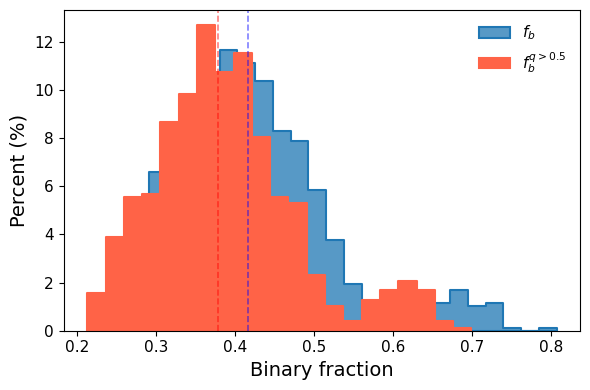

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))


sns.histplot(
    data=df, x="bin_frac_corr",
    element="step", stat="percent",
    linewidth=1.5, ax=ax, label=r"$f_b$"
)

sns.histplot(
    data=df, x="bin_frac_05_corr",
    element="step", stat="percent",
    linewidth=1.5, color="tomato",
    ax=ax, label=r"$f_b^{q>0.5}$",
    alpha=1
)

ax.axvline(df.bin_frac_corr.median(), ls="--", lw=1.2, color='b', alpha=0.5)
ax.axvline(df.bin_frac_05_corr.median(), ls="--", lw=1.2, color="r", alpha=0.5)

ax.set_xlabel("Binary fraction", fontdict=font)
ax.set_ylabel("Percent (%)", fontdict=font)

ax.tick_params(labelsize=11,)
ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
#plt.savefig("Figures/dist_fb.png", dpi=300, bbox_inches="tight")
plt.show()


## Cluster properties

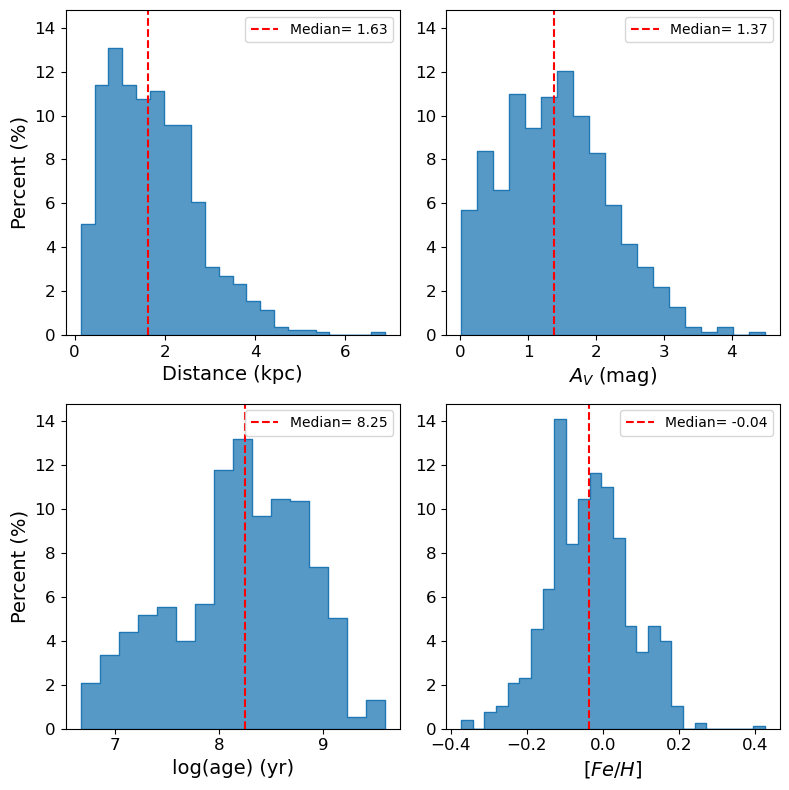

In [6]:
fig, axs = plt.subplots(2,2, figsize = (8,8), sharey=True)

sns.histplot(data=df, x='dist', ax = axs[0,0], stat='percent', element='step',)
axs[0,0].set_xlabel('Distance (kpc)', fontdict=font)
axs[0,0].axvline(x=df['dist'].median(), color='r',ls='--',  label = f'Median= {df.dist.median():.2f}')
axs[0,0].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[0, 0].legend()


sns.histplot(data=df, x='Av', ax = axs[0,1], stat='percent', element='step')
axs[0,1].set_xlabel(r'$A_V$ (mag)', fontdict=font)
axs[0,1].axvline(x=df['Av'].median(), color='r',ls='--', label = f'Median= {df.Av.median():.2f}')
axs[0,1].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[0, 1].legend()

sns.histplot(data=df, x='age', ax = axs[1,0], stat='percent', element='step')
axs[1,0].set_xlabel('log(age) (yr)', fontdict=font)
axs[1,0].axvline(x=df['age'].median(), color='r',ls='--', label = f'Median= {df.age.median():.2f}')
axs[1,0].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[1, 0].legend()

sns.histplot(data=df, x='FeH', ax = axs[1,1], stat='percent', element='step')
axs[1,1].set_xlabel(r'[$Fe/H$]', fontdict=font)
axs[1,1].axvline(x=df['FeH'].median(), color='r',ls='--', label = f'Median= {df.FeH.median():.2f}')
axs[1,1].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[1,1].legend()

axs[0,0].set_ylabel('Percent (%)', fontdict=font)
axs[1,0].set_ylabel('Percent (%)', fontdict=font)



plt.tight_layout()
#plt.savefig('Figures/clusters_properties.png',bbox_inches='tight', dpi=300)
plt.show()

## Mass ratios

In [7]:
data[data['q']>0]['q'].describe().round(2)

count    63605.00
mean         0.74
std          0.14
min          0.34
25%          0.62
50%          0.76
75%          0.87
max          0.99
Name: q, dtype: float64

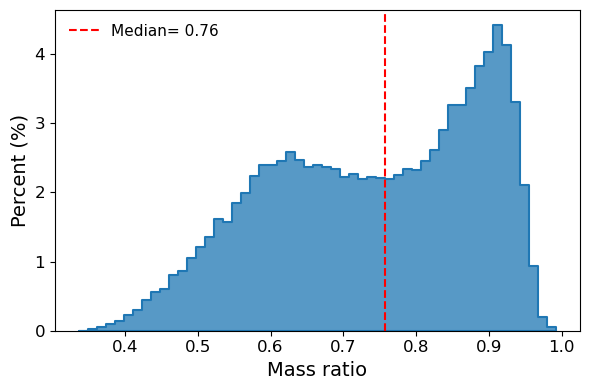

In [8]:
fig= plt.figure(figsize= (6,4))
sns.histplot(x=data[data.q>0]['q'], stat='percent', element='step', lw=1.5)
median = data[data.q>0]['q'].median()
plt.axvline(median, ls='--', c='r', label = f'Median= {median:.2f}')

plt.xlabel('Mass ratio', fontdict=font)
plt.ylabel('Percent (%)', fontdict=font)
plt.tick_params(labelsize=labelsize)
plt.legend(frameon=False, fontsize=11, loc='upper left')
plt.tight_layout()
#plt.savefig('Figures/dist_mass_ratio.png',  dpi=300, bbox_inches="tight")
plt.show()

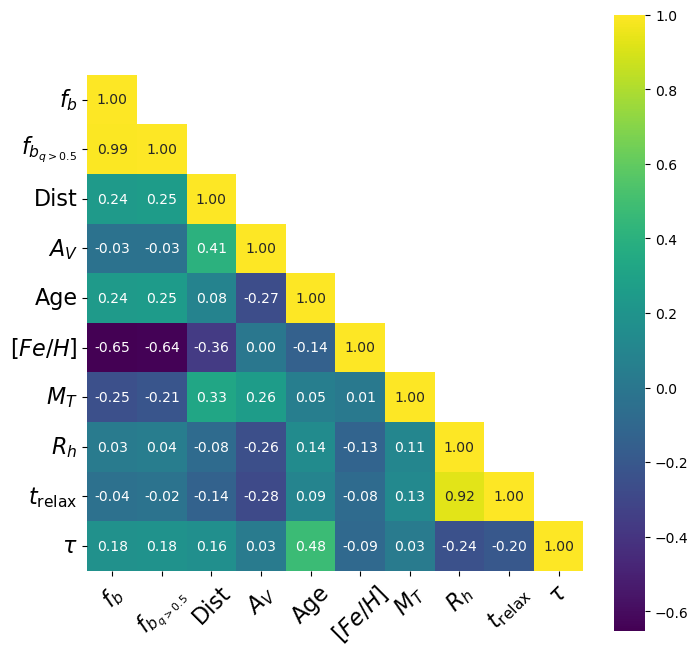

In [9]:
nome_vars = {
    'bin_frac_corr': r'$f_b$',
    'bin_frac_05_corr': r'$f_{b_{q>0.5}}$',
    'dist': r'Dist',
    'Av': r'$A_V$',
    'age': r'Age',
    'FeH': r'[$Fe/H$]',
    'mass_total': r'$M_T$',
    'rh': r'$R_h$',
    't_relax': r'$t_{\mathrm{relax}}$',
    'tau': r'$\tau$',
}

cols = list(nome_vars.keys())
corr = df[cols].corr(method='pearson')
corr.rename(index=nome_vars, columns=nome_vars, inplace=True)

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig = plt.figure(figsize=(8, 8))
cmap = palette 

ax = sns.heatmap(corr, mask=mask, annot=True, cmap=cmap, fmt=".2f", square=True, cbar=True,)

for label in ax.get_xticklabels():
    label.set_fontsize(16)
    label.set_rotation(45) 

for label in ax.get_yticklabels():
    label.set_fontsize(16)
    label.set_rotation(0) 

#plt.savefig('Figures/corr.png',bbox_inches='tight')
plt.show()

# Benchmark subsample description

In [10]:
benchmark[['dist','age', 'FeH', 'Av', 'mass_total', 'n_members', 
    'bin_frac_corr','er_bin_frac', 'bin_frac_05_corr', 'er_bin_frac_05']].describe().round(2)

,dist,age,FeH,Av,mass_total,n_members,bin_frac_corr,er_bin_frac,bin_frac_05_corr,er_bin_frac_05
count,96.00,96.00,96.00,96.00,96.00,96.00,96.00,96.00,96.00,96.00
mean,0.62,8.24,-0.02,0.27,364.80,380.65,0.41,0.08,0.37,0.08
std,0.29,0.56,0.08,0.14,290.16,286.92,0.09,0.07,0.09,0.07
min,0.14,6.74,-0.23,0.01,63.00,68.00,0.25,0.01,0.22,0.01
25%,0.39,7.82,-0.06,0.18,190.50,186.50,0.35,0.03,0.31,0.03
50%,0.60,8.31,-0.02,0.27,292.00,321.50,0.42,0.05,0.38,0.05
75%,0.78,8.61,0.01,0.36,398.00,505.25,0.47,0.11,0.43,0.11
max,1.37,9.58,0.18,0.49,1843.00,1551.00,0.71,0.38,0.63,0.30


In [11]:
print(f'N clusters in benchmark: {len(benchmark)}')

N clusters in benchmark: 96


## Binary fraction

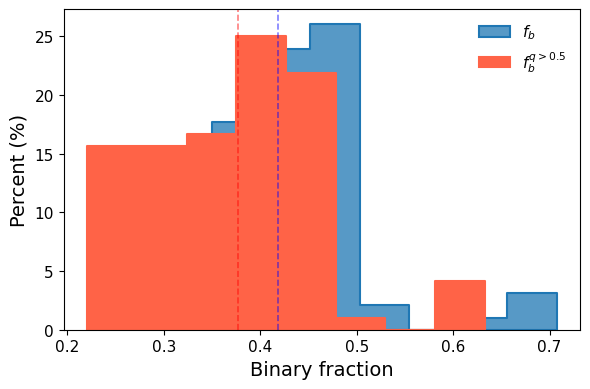

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))


sns.histplot(
    data=benchmark, x="bin_frac_corr",
    element="step", stat="percent",
    linewidth=1.5, ax=ax, label=r"$f_b$"
)

sns.histplot(
    data=benchmark, x="bin_frac_05_corr",
    element="step", stat="percent",
    linewidth=1.5, color="tomato",
    ax=ax, label=r"$f_b^{q>0.5}$",
    alpha=1
)

ax.axvline(benchmark.bin_frac_corr.median(), ls="--", lw=1.2, color='b', alpha=0.5)
ax.axvline(benchmark.bin_frac_05_corr.median(), ls="--", lw=1.2, color="r", alpha=0.5)

ax.set_xlabel("Binary fraction", fontdict=font)
ax.set_ylabel("Percent (%)", fontdict=font)

ax.tick_params(labelsize=11,)
ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.show()

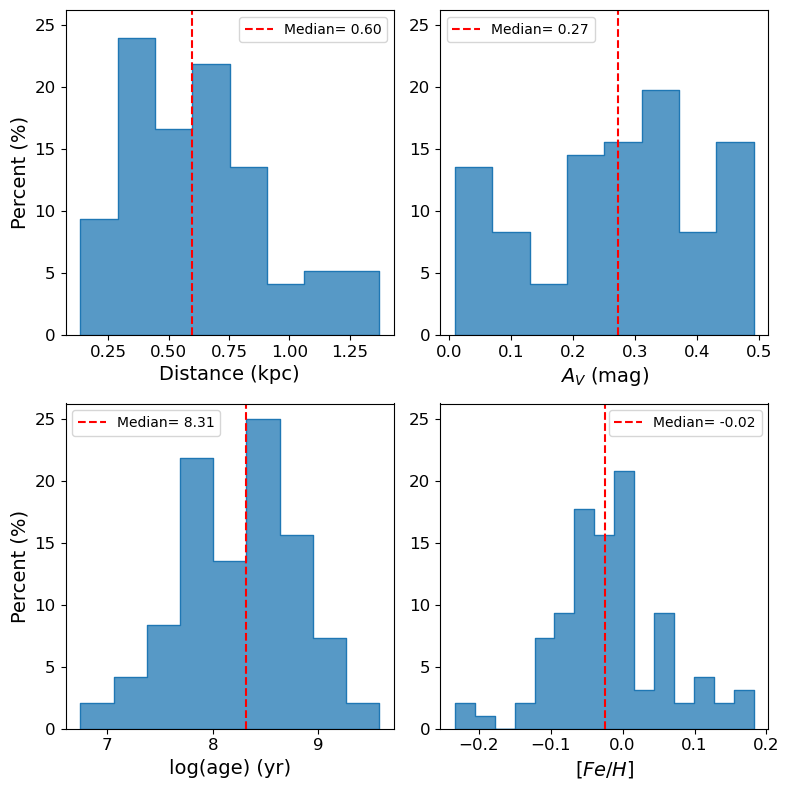

In [13]:
fig, axs = plt.subplots(2,2, figsize = (8,8), sharey=True)

sns.histplot(data=benchmark, x='dist', ax = axs[0,0], stat='percent', element='step',)
axs[0,0].set_xlabel('Distance (kpc)', fontdict=font)
axs[0,0].axvline(x=benchmark['dist'].median(), color='r',ls='--',  label = f'Median= {benchmark.dist.median():.2f}')
axs[0,0].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[0, 0].legend()


sns.histplot(data=benchmark, x='Av', ax = axs[0,1], stat='percent', element='step')
axs[0,1].set_xlabel(r'$A_V$ (mag)', fontdict=font)
axs[0,1].axvline(x=benchmark['Av'].median(), color='r',ls='--', label = f'Median= {benchmark.Av.median():.2f}')
axs[0,1].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[0, 1].legend()

sns.histplot(data=benchmark, x='age', ax = axs[1,0], stat='percent', element='step')
axs[1,0].set_xlabel('log(age) (yr)', fontdict=font)
axs[1,0].axvline(x=benchmark['age'].median(), color='r',ls='--', label = f'Median= {benchmark.age.median():.2f}')
axs[1,0].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[1, 0].legend()

sns.histplot(data=benchmark, x='FeH', ax = axs[1,1], stat='percent', element='step')
axs[1,1].set_xlabel(r'[$Fe/H$]', fontdict=font)
axs[1,1].axvline(x=benchmark['FeH'].median(), color='r',ls='--', label = f'Median= {benchmark.FeH.median():.2f}')
axs[1,1].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[1,1].legend()

axs[0,0].set_ylabel('Percent (%)', fontdict=font)
axs[1,0].set_ylabel('Percent (%)', fontdict=font)



plt.tight_layout()
plt.show()

In [14]:
data_bench = data.loc[benchmark.index]
data_bench[data_bench['q']>0]['q'].describe().round(2)

count    7968.00
mean        0.72
std         0.15
min         0.35
25%         0.60
50%         0.74
75%         0.86
max         0.99
Name: q, dtype: float64

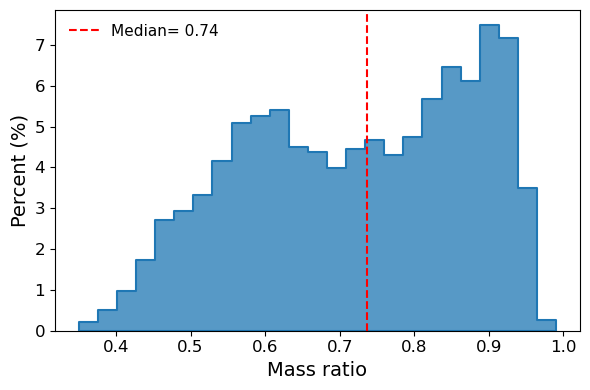

In [15]:
fig= plt.figure(figsize= (6,4))
sns.histplot(x=data_bench[data_bench.q>0]['q'], stat='percent', element='step', lw=1.5)
median = data_bench[data_bench.q>0]['q'].median()
plt.axvline(median, ls='--', c='r', label = f'Median= {median:.2f}')

plt.xlabel('Mass ratio', fontdict=font)
plt.ylabel('Percent (%)', fontdict=font)
plt.tick_params(labelsize=labelsize)
plt.legend(frameon=False, fontsize=11, loc='upper left')
plt.tight_layout()
plt.show()

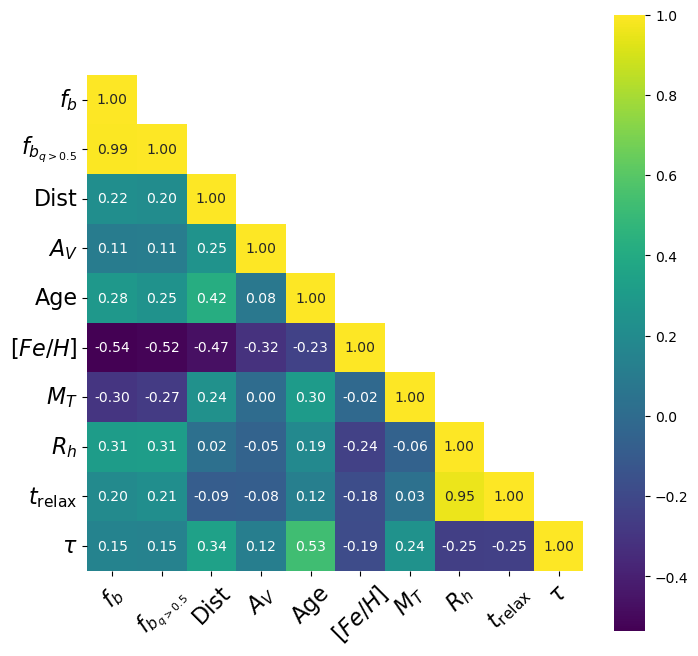

In [16]:
nome_vars = {
    'bin_frac_corr': r'$f_b$',
    'bin_frac_05_corr': r'$f_{b_{q>0.5}}$',
    'dist': r'Dist',
    'Av': r'$A_V$',
    'age': r'Age',
    'FeH': r'[$Fe/H$]',
    'mass_total': r'$M_T$',
    'rh': r'$R_h$',
    't_relax': r'$t_{\mathrm{relax}}$',
    'tau': r'$\tau$',
}

cols = list(nome_vars.keys())
corr = benchmark[cols].corr(method='pearson')
corr.rename(index=nome_vars, columns=nome_vars, inplace=True)

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig = plt.figure(figsize=(8, 8))
cmap = palette 

ax = sns.heatmap(corr, mask=mask, annot=True, cmap=cmap, fmt=".2f", square=True, cbar=True,)

for label in ax.get_xticklabels():
    label.set_fontsize(16)
    label.set_rotation(45) 

for label in ax.get_yticklabels():
    label.set_fontsize(16)
    label.set_rotation(0) 


plt.show()

# comparison of the two samples

In [17]:
print('================================================================================')
print('Full sample')
print(df[['age', 'FeH', 'mass_total', 'n_members',]].describe().round(2).T)
print('================================================================================\n')
print('================================================================================')
print('benchmark sample')
print(benchmark[['age', 'FeH', 'mass_total', 'n_members',]].describe().round(2).T)
print('================================================================================')

Full sample
            count    mean     std    min     25%     50%     75%      max
age         773.0    8.18    0.63   6.67    7.79    8.25    8.67     9.59
FeH         773.0   -0.04    0.11  -0.37   -0.11   -0.04    0.03     0.43
mass_total  773.0  544.27  447.10  61.00  245.00  413.00  679.00  3434.00
n_members   773.0  320.95  247.55  43.00  153.00  250.00  406.00  1551.00

benchmark sample
            count    mean     std    min     25%     50%     75%      max
age          96.0    8.24    0.56   6.74    7.82    8.31    8.61     9.58
FeH          96.0   -0.02    0.08  -0.23   -0.06   -0.02    0.01     0.18
mass_total   96.0  364.80  290.16  63.00  190.50  292.00  398.00  1843.00
n_members    96.0  380.65  286.92  68.00  186.50  321.50  505.25  1551.00


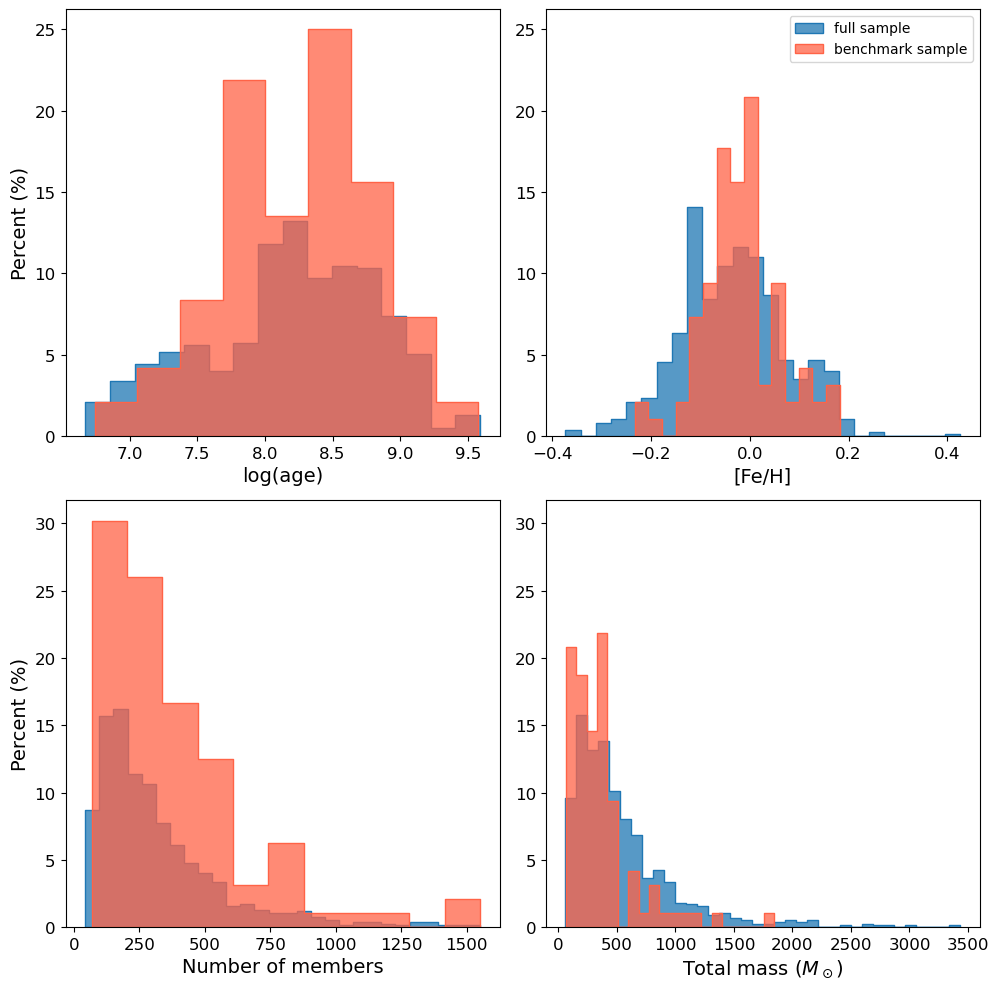

In [18]:
params = ['age', 'FeH', 'n_members', 'mass_total']
labels = ['log(age)', '[Fe/H]', 'Number of members', r'Total mass ($M_\odot$)']

fig, ax = plt.subplots(2,2, figsize = (10,10), sharey='row')
i, j = 0 , 0
for param, label in zip(params, labels):
    if j >1:
        j=0
        i=1
    sns.histplot(data = df, x = param, label = 'full sample', element = 'step', stat = 'percent', ax = ax[i,j])
    sns.histplot(data = benchmark, x = param, label = 'benchmark sample', element = 'step', stat = 'percent', ax = ax[i,j], color = 'tomato')
    ax[i,j].tick_params(labelleft=True, labelbottom=True, labelsize=12)
    ax[i,j].set_xlabel(label, fontdict = font)
    ax[i,j].set_ylabel('Percent (%)', fontdict = font)
    j +=1
    
    
ax[0,1].legend()
plt.tight_layout()
#plt.savefig('Figures/benchmark_properties.png',bbox_inches='tight', dpi=300)
plt.show()

In [19]:
for param in params:
    print('============================================')
    print(param)
    statistical_test(df[param], benchmark[param])
    print('============================================\n')

age
KS test: stat = 0.0886, p = 4.84e-01
Não há evidência de que são diferentes

Mann–Whitney U test: U = 35974.5000, p = 6.2644e-01
Não há evidência de que são diferentes

Anderson–Darling test: stat = -0.3166, p = 2.5000e-01
Não há evidência de que são diferentes


FeH
KS test: stat = 0.2152, p = 5.95e-04
Distribuições distintas

Mann–Whitney U test: U = 33066.5000, p = 8.1774e-02
Não há evidência de que são diferentes

Anderson–Darling test: stat = 4.9075, p = 3.7447e-03
Distribuições distintas


n_members
KS test: stat = 0.1419, p = 5.77e-02
Não há evidência de que são diferentes

Mann–Whitney U test: U = 31807.5000, p = 2.2415e-02
Distribuições distintas

Anderson–Darling test: stat = 2.4463, p = 3.2217e-02
Distribuições distintas


mass_total
KS test: stat = 0.2765, p = 2.92e-06
Distribuições distintas

Mann–Whitney U test: U = 47907.5000, p = 3.2009e-06
Distribuições distintas

Anderson–Darling test: stat = 13.3886, p = 1.0000e-03
Distribuições distintas


